# Spectral GC: Testing on NHP LFP Recordings

This notebook applies bivariate spectral Granger causality (GC) analysis to real non-human primate (NHP) local field potential (LFP) recordings comprising **332 trials**, **2 regions of interest (ROIs)**, and **2150 samples per trial** acquired at **1000 Hz**. Spectral GC is computed using all four spectral estimation backends available in `pygc`:

| `spectral_method` | Estimator                         | Notes                                                    |
| ----------------- | --------------------------------- | -------------------------------------------------------- |
| `'multitaper'`    | Multitaper (DPSS) CSD via MNE     | Reduced spectral leakage; `bandwidth` controls smoothing |
| `'welch'`         | Welch overlapping-window average  | Robust averaging with fixed `nperseg`                    |
| `'fourier'`       | Trial-averaged FFT periodogram    | Maximum frequency resolution                             |

In addition to spectral GC, we examine the **power spectra** and **spectral coherence** of both LFP channels to characterize their oscillatory activity and frequency-specific coupling.

The analyses reveal a prominent interaction around **35 Hz**, where both the power and coherence spectra indicate strong shared oscillatory activity between the two ROIs. The spectral GC estimates further demonstrate that this coupling is not merely symmetric synchronization: they successfully identify the dominant direction of information flow, disentangling the causal influence between the two LFP signals at this frequency.

The data used in this example is one channel pair from the dataset originally published by Dotson et. al. (2017) [[link to the original publication](10.1016/j.neuron.2017.09.050)].

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from pygc.granger import granger_causality
from pygc.spectral_analysis import multitaper_spectrum, welch_spectrum

plt.rcParams.update({"figure.dpi": 100, "font.size": 12})

In [2]:
data = xr.load_dataarray("data/data.nc")

In [3]:
FS = data.attrs["fsample"]  # sampling rate (Hz)
BANDWIDTH = 4.0              # multitaper bandwidth (Hz)
FMAX = 80                    # max frequency for plots
MORLET_FREQS = np.arange(1, FMAX + 1, 2.0)  # 1–80 Hz in 2-Hz steps

data_np = data.values  # (trials, roi, time) numpy array
print(f"Data: {data_np.shape[0]} trials, {data_np.shape[1]} channels, "
      f"{data_np.shape[2]} samples  @ {FS:.0f} Hz")

Data: 332 trials, 2 channels, 2150 samples  @ 1000 Hz


## Granger Causality — Welch method


/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


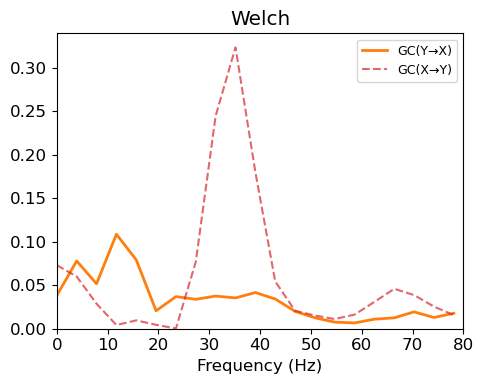

In [4]:
ds_wl = granger_causality(
    data_np, FS, spectral_method="welch", Niterations=200, verbose=False,
)

Ix2y_wl, Iy2x_wl, f_wl = ds_wl["x2y"][0], ds_wl["y2x"][0], ds_wl["freq"]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_wl <= FMAX
ax.plot(f_wl[mask], Iy2x_wl[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_wl[mask], Ix2y_wl[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Welch")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Granger Causality — Fourier method


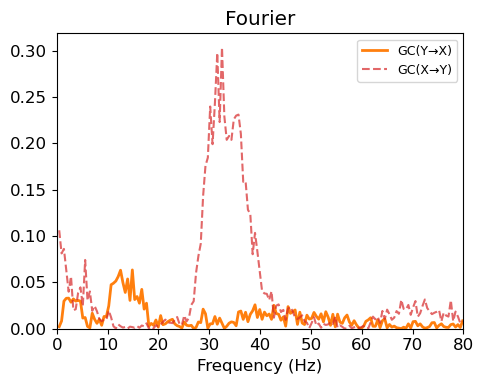

In [5]:
ds_fft = granger_causality(
    data_np, FS, spectral_method="fourier", Niterations=200, verbose=False,
)

Ix2y_fft, Iy2x_fft, f_fft = ds_fft["x2y"][0], ds_fft["y2x"][0], ds_fft["freq"]


fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_fft <= FMAX
ax.plot(f_fft[mask], Iy2x_fft[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_fft[mask], Ix2y_fft[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Fourier")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Granger Causality — Multitaper method

/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/anaconda3/envs/test_env/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


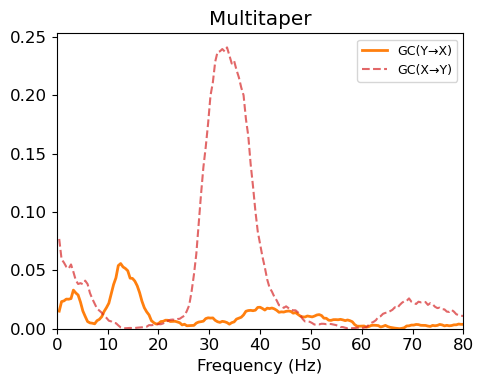

In [6]:
ds_mt = granger_causality(
    data, FS, spectral_method="multitaper", Niterations=200, verbose=False,
    spectral_params={"bandwidth": BANDWIDTH},
)

Ix2y_mt, Iy2x_mt, f_mt = ds_mt["x2y"][0], ds_mt["y2x"][0], ds_mt["freq"]

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
mask = f_mt <= FMAX
ax.plot(f_mt[mask], Iy2x_mt[mask], color="C1", lw=2, label="GC(Y→X)")
ax.plot(f_mt[mask], Ix2y_mt[mask], color="C3", lw=1.5,
        linestyle="--", alpha=0.7, label="GC(X→Y)")
ax.set_title("Multitaper")
ax.set_xlabel("Frequency (Hz)")
ax.set_xlim([0, FMAX])
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
plt.tight_layout()

## Comparison: All Three Methods


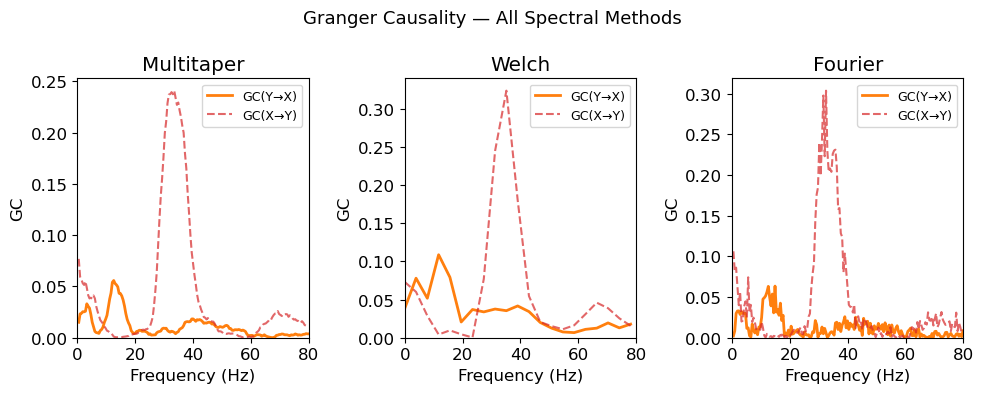

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes = axes.ravel()

methods = [
    ("Multitaper", f_mt, Iy2x_mt, Ix2y_mt),
    ("Welch",      f_wl, Iy2x_wl,  Ix2y_wl),
    ("Fourier",    f_fft, Iy2x_fft, Ix2y_fft),
]

for ax, (title, f, iy2x, ix2y) in zip(axes, methods):
    mask = f <= FMAX
    ax.plot(f[mask], iy2x[mask], color="C1", lw=2, label="GC(Y\u2192X)")
    ax.plot(f[mask], ix2y[mask], color="C3", lw=1.5,
            linestyle="--", alpha=0.7, label="GC(X\u2192Y)")
    ax.set_title(title)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("GC")
    ax.set_xlim([0, FMAX])
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)

plt.suptitle("Granger Causality — All Spectral Methods", fontsize=13)
plt.tight_layout()